Air pollution poses a significant threat to human health and the environment, with PM2.5 (particulate matter with a diameter of 2.5 micrometers or smaller) being one of the most critical pollutants due to its ability to penetrate deep into the lungs and bloodstream.

**In this study, I aim to leverage data provided by the Environmental Protection Sub-department of Hanoi to build regression models that accurately predict PM2.5 levels.** 

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, boxcox

In [44]:
df_1 = pd.read_excel('72. Hà Nội_ Chi cục BVMT (KK)_20210906_100737.xlsx')
df_2 = pd.read_excel('72. Hà Nội_ Chi cục BVMT (KK)_20211111_160610.xlsx')
df_3 = pd.read_excel('72. Hà Nội_ Chi cục BVMT (KK)_20220321_085841.xlsx')

To facilitate data understanding and processing, I combine 3 data files into 1 dataframe

In [45]:
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15072 entries, 0 to 15071
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Datetime           15072 non-null  object 
 1   NHIệT độ           15072 non-null  object 
 2   NOX                15072 non-null  float64
 3   SO2                15072 non-null  object 
 4   O3                 15072 non-null  float64
 5   PM-10              15072 non-null  object 
 6   PM-2-5             15072 non-null  object 
 7   NO                 15072 non-null  float64
 8   NO2                15072 non-null  float64
 9   CO                 15072 non-null  object 
 10  ÁP SUấT KHí QUYểN  15072 non-null  object 
 11  RADIATION          15072 non-null  object 
 12  RH                 15072 non-null  object 
 13  HướNG GIó          15072 non-null  object 
 14  TốC độ GIó         15072 non-null  object 
 15  LượNG MưA          15072 non-null  object 
dtypes: float64(4), object(

(           Datetime NHIệT độ    NOX   SO2    O3  PM-10 PM-2-5     NO    NO2  \
 0  21:00 25/02/2020     22.2  48.80  6.43  7.08  76.14  50.19  10.25  33.14   
 1  22:00 25/02/2020     21.5  63.05  6.25  4.16  75.28  47.97  16.26  38.20   
 2  23:00 25/02/2020     21.3  62.61  5.55  3.36  72.97  51.11  16.93  36.75   
 3  00:00 26/02/2020     21.2  61.86  6.68  4.76  77.43  53.45  16.80  36.18   
 4  01:00 26/02/2020       21  84.88  5.39  1.54  69.16  52.04  27.21  43.30   
 
        CO ÁP SUấT KHí QUYểN RADIATION    RH HướNG GIó TốC độ GIó LượNG MưA  
 0   998.1            1013.4       7.4  69.1       150        2.4         0  
 1   791.8            1013.6       6.9  72.7       151        1.7         0  
 2     894            1013.5       6.4  71.6       148        1.9         0  
 3  1117.9            1013.4       6.7  70.4       149          2         0  
 4   652.8            1013.2       6.6  73.3       149        1.8         0  ,
 None)

Convert datatype to float

In [46]:
columns = [
    "NHIệT độ", "SO2", "PM-10", "PM-2-5", "CO", 
    "ÁP SUấT KHí QUYểN", "RADIATION", "RH", 
    "HướNG GIó", "TốC độ GIó", "LượNG MưA"
]

for col in df[columns]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')


C:\Users\tranl\AppData\Local\Temp\ipykernel_2592\135538639.py:10: UserWarning: Parsing dates in %H:%M %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')


In [47]:
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15072 entries, 0 to 15071
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Datetime           15072 non-null  datetime64[ns]
 1   NHIệT độ           15067 non-null  float64       
 2   NOX                15072 non-null  float64       
 3   SO2                15070 non-null  float64       
 4   O3                 15072 non-null  float64       
 5   PM-10              15065 non-null  float64       
 6   PM-2-5             15059 non-null  float64       
 7   NO                 15072 non-null  float64       
 8   NO2                15072 non-null  float64       
 9   CO                 15070 non-null  float64       
 10  ÁP SUấT KHí QUYểN  13730 non-null  float64       
 11  RADIATION          13730 non-null  float64       
 12  RH                 13730 non-null  float64       
 13  HướNG GIó          13730 non-null  float64       
 14  TốC độ

(             Datetime  NHIệT độ    NOX   SO2    O3  PM-10  PM-2-5     NO  \
 0 2020-02-25 21:00:00      22.2  48.80  6.43  7.08  76.14   50.19  10.25   
 1 2020-02-25 22:00:00      21.5  63.05  6.25  4.16  75.28   47.97  16.26   
 2 2020-02-25 23:00:00      21.3  62.61  5.55  3.36  72.97   51.11  16.93   
 3 2020-02-26 00:00:00      21.2  61.86  6.68  4.76  77.43   53.45  16.80   
 4 2020-02-26 01:00:00      21.0  84.88  5.39  1.54  69.16   52.04  27.21   
 
      NO2      CO  ÁP SUấT KHí QUYểN  RADIATION    RH  HướNG GIó  TốC độ GIó  \
 0  33.14   998.1             1013.4        7.4  69.1      150.0         2.4   
 1  38.20   791.8             1013.6        6.9  72.7      151.0         1.7   
 2  36.75   894.0             1013.5        6.4  71.6      148.0         1.9   
 3  36.18  1117.9             1013.4        6.7  70.4      149.0         2.0   
 4  43.30   652.8             1013.2        6.6  73.3      149.0         1.8   
 
    LượNG MưA  
 0        0.0  
 1        0.0  
 2    

Missing values can skew the result of regression model or lead to errors during training. So that, handling them ensures the data is complete and reliable for analysis

**Because the large of the dataset, so I decide to drop all row of missing values**

In [48]:
df.isnull().sum()

Datetime                0
NHIệT độ                5
NOX                     0
SO2                     2
O3                      0
PM-10                   7
PM-2-5                 13
NO                      0
NO2                     0
CO                      2
ÁP SUấT KHí QUYểN    1342
RADIATION            1342
RH                   1342
HướNG GIó            1342
TốC độ GIó           1342
LượNG MưA            1342
dtype: int64

In [49]:
df = df.dropna(axis=0)
df.head(), df.isnull().sum()

(             Datetime  NHIệT độ    NOX   SO2    O3  PM-10  PM-2-5     NO  \
 0 2020-02-25 21:00:00      22.2  48.80  6.43  7.08  76.14   50.19  10.25   
 1 2020-02-25 22:00:00      21.5  63.05  6.25  4.16  75.28   47.97  16.26   
 2 2020-02-25 23:00:00      21.3  62.61  5.55  3.36  72.97   51.11  16.93   
 3 2020-02-26 00:00:00      21.2  61.86  6.68  4.76  77.43   53.45  16.80   
 4 2020-02-26 01:00:00      21.0  84.88  5.39  1.54  69.16   52.04  27.21   
 
      NO2      CO  ÁP SUấT KHí QUYểN  RADIATION    RH  HướNG GIó  TốC độ GIó  \
 0  33.14   998.1             1013.4        7.4  69.1      150.0         2.4   
 1  38.20   791.8             1013.6        6.9  72.7      151.0         1.7   
 2  36.75   894.0             1013.5        6.4  71.6      148.0         1.9   
 3  36.18  1117.9             1013.4        6.7  70.4      149.0         2.0   
 4  43.30   652.8             1013.2        6.6  73.3      149.0         1.8   
 
    LượNG MưA  
 0        0.0  
 1        0.0  
 2    

Overview of the dataset

In [50]:
df.describe().round(2)

,Datetime,NHIệT độ,NOX,SO2,O3,PM-10,PM-2-5,NO,NO2,CO,ÁP SUấT KHí QUYểN,RADIATION,RH,HướNG GIó,TốC độ GIó,LượNG MưA
count,13720,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00,13720.00
mean,2021-01-18 10:01:51.450437120,23.73,32.69,1.53,8.00,62.48,37.37,6.50,22.82,894.05,960.05,141.23,61.56,143.20,1.37,0.12
min,2020-02-25 21:00:00,0.00,0.00,0.00,0.00,0.00,0.00,-7.27,-2.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2020-08-05 18:45:00,20.00,15.60,0.00,0.00,33.66,20.33,1.10,11.15,481.90,1002.00,6.90,53.40,52.00,0.90,0.00
50%,2020-12-30 01:30:00,24.50,28.36,1.70,2.50,52.47,32.40,5.54,19.67,763.75,1007.50,8.90,65.70,143.00,1.30,0.00
75%,2021-08-03 10:15:00,28.70,42.29,2.58,11.75,79.28,48.56,6.79,30.92,1144.53,1013.70,191.82,75.30,180.00,1.80,0.00
max,2021-12-31 23:00:00,40.60,683.78,18.10,231.19,393.56,529.55,378.60,246.25,9946.10,1028.60,1030.70,93.70,360.00,5.60,42.72
std,NaN,7.55,26.53,1.29,12.39,45.25,28.37,10.23,16.99,660.85,215.20,223.72,18.93,100.61,0.74,1.15


PM2.5 is my target variable, and understanding its distribution is essential.

**Visualizing the distribution of PM2.5 can check if it’s skewed or normally distributed.**

Original Skewness: 1.9347015805407073


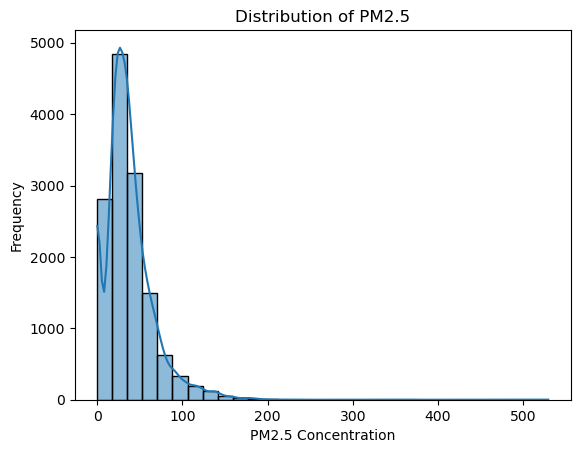

In [51]:
original_skewness = skew(df['PM-2-5'])
print(f"Original Skewness: {original_skewness}")

sns.histplot(df['PM-2-5'], kde=True, bins=30)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Frequency')
plt.show()

Based on the distribution figure i can evaluate that the distribution of PM2.5 is skewed. Specifically, it is right-skewed (positively skewed) because:

- The peak of the distribution is concentrated on the lower end of the PM2.5 values.
- There is a long tail extending towards higher PM2.5 values.

**To address the right-skewed distribution, I apply Square Root Transformation to make the data more symmetric and closer to a normal distribution.**

Square Root-Transformed Skewness: -0.349347528823149


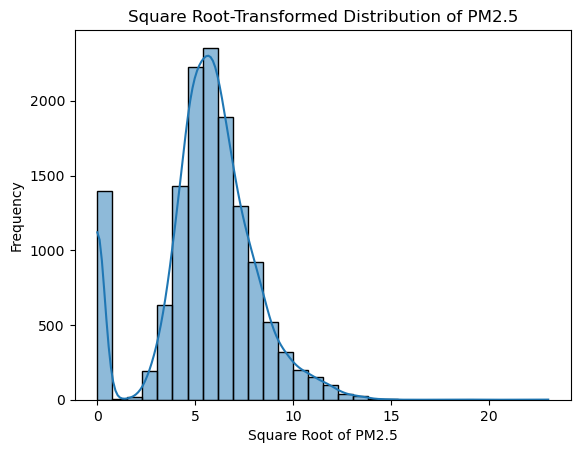

In [52]:
df['PM-2.5_sqrt'] = np.sqrt(df['PM-2-5'])

sqrt_skewness = skew(df['PM-2.5_sqrt'])
print(f"Square Root-Transformed Skewness: {sqrt_skewness}")

sns.histplot(df['PM-2.5_sqrt'], kde=True, bins=30)
plt.title('Square Root-Transformed Distribution of PM2.5')
plt.xlabel('Square Root of PM2.5')
plt.ylabel('Frequency')
plt.show()

Log-Transformed Skewness: -1.7092175934218117


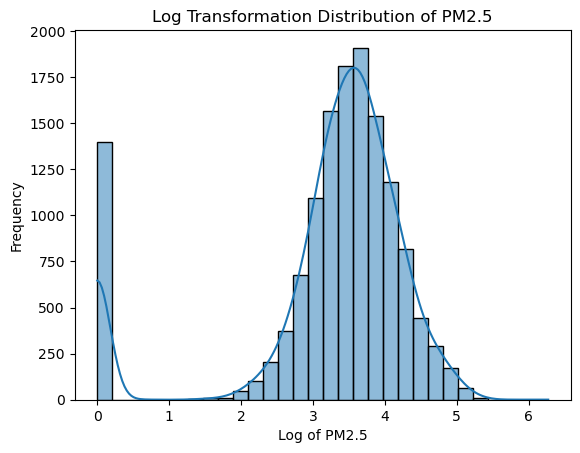

In [53]:
df['PM-2.5_log'] = np.log1p(df['PM-2-5'])

log_skewness = skew(df['PM-2.5_log'])
print(f"Log-Transformed Skewness: {log_skewness}")

sns.histplot(df['PM-2.5_log'], kde=True, bins=30)
plt.title('Log Transformation Distribution of PM2.5')
plt.xlabel('Log of PM2.5')
plt.ylabel('Frequency')
plt.show()

boxcox Skewness: -0.019166352772314668


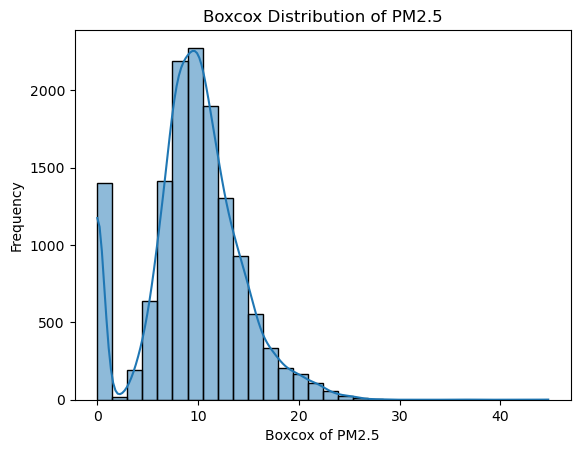

In [54]:
df['PM-2.5_boxcox'], _ = boxcox(df['PM-2-5'] + 1)

boxcox_skewness = skew(df['PM-2.5_boxcox'])
print(f"boxcox Skewness: {boxcox_skewness}")

sns.histplot(df['PM-2.5_boxcox'], kde=True, bins=30)
plt.title('Boxcox Distribution of PM2.5')
plt.xlabel('Boxcox of PM2.5')
plt.ylabel('Frequency')
plt.show()

A correlation heatmap identifies relationships between numerical features, helping me understand which variables are strongly associated with PM2.5.

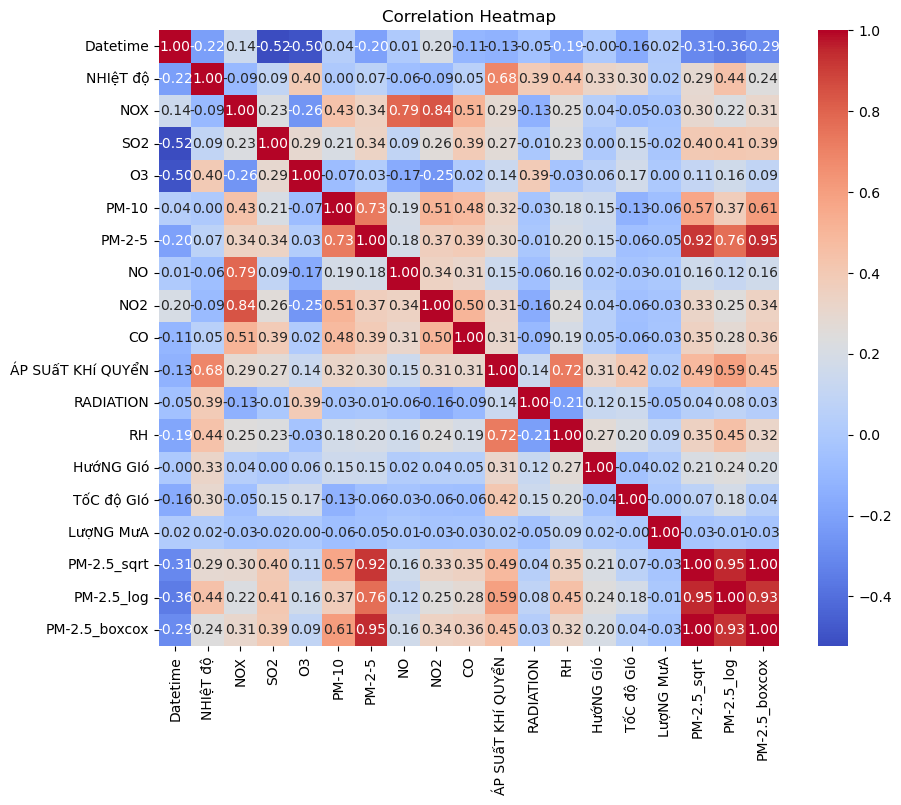

In [55]:
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


Based on the heatmap figure i can select features which is the relatest to PM2.5 such as:
- Nox
- SO2
- PM10
- NO2
- CO
- ÁP SUấT KHí QUYểN
- Rh
- HướNG GIó

Beside that temperature also has a close relationship in reality, so I will select temperature as well.

After important features selected, i detect and handle outlier values of each features to improving performance when building models.

In [56]:
def cap_outliers_iqr(df, columns):
    for column in columns:
        Q1 = np.percentile(df[column].dropna(), 25)
        Q3 = np.percentile(df[column].dropna(), 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    
    return df

columns_to_check = ['NHIệT độ', 'NOX', 'SO2', 'PM-10', 'NO2', 'CO', 'ÁP SUấT KHí QUYểN', 'RH', 'HướNG GIó']

df = cap_outliers_iqr(df, columns_to_check)

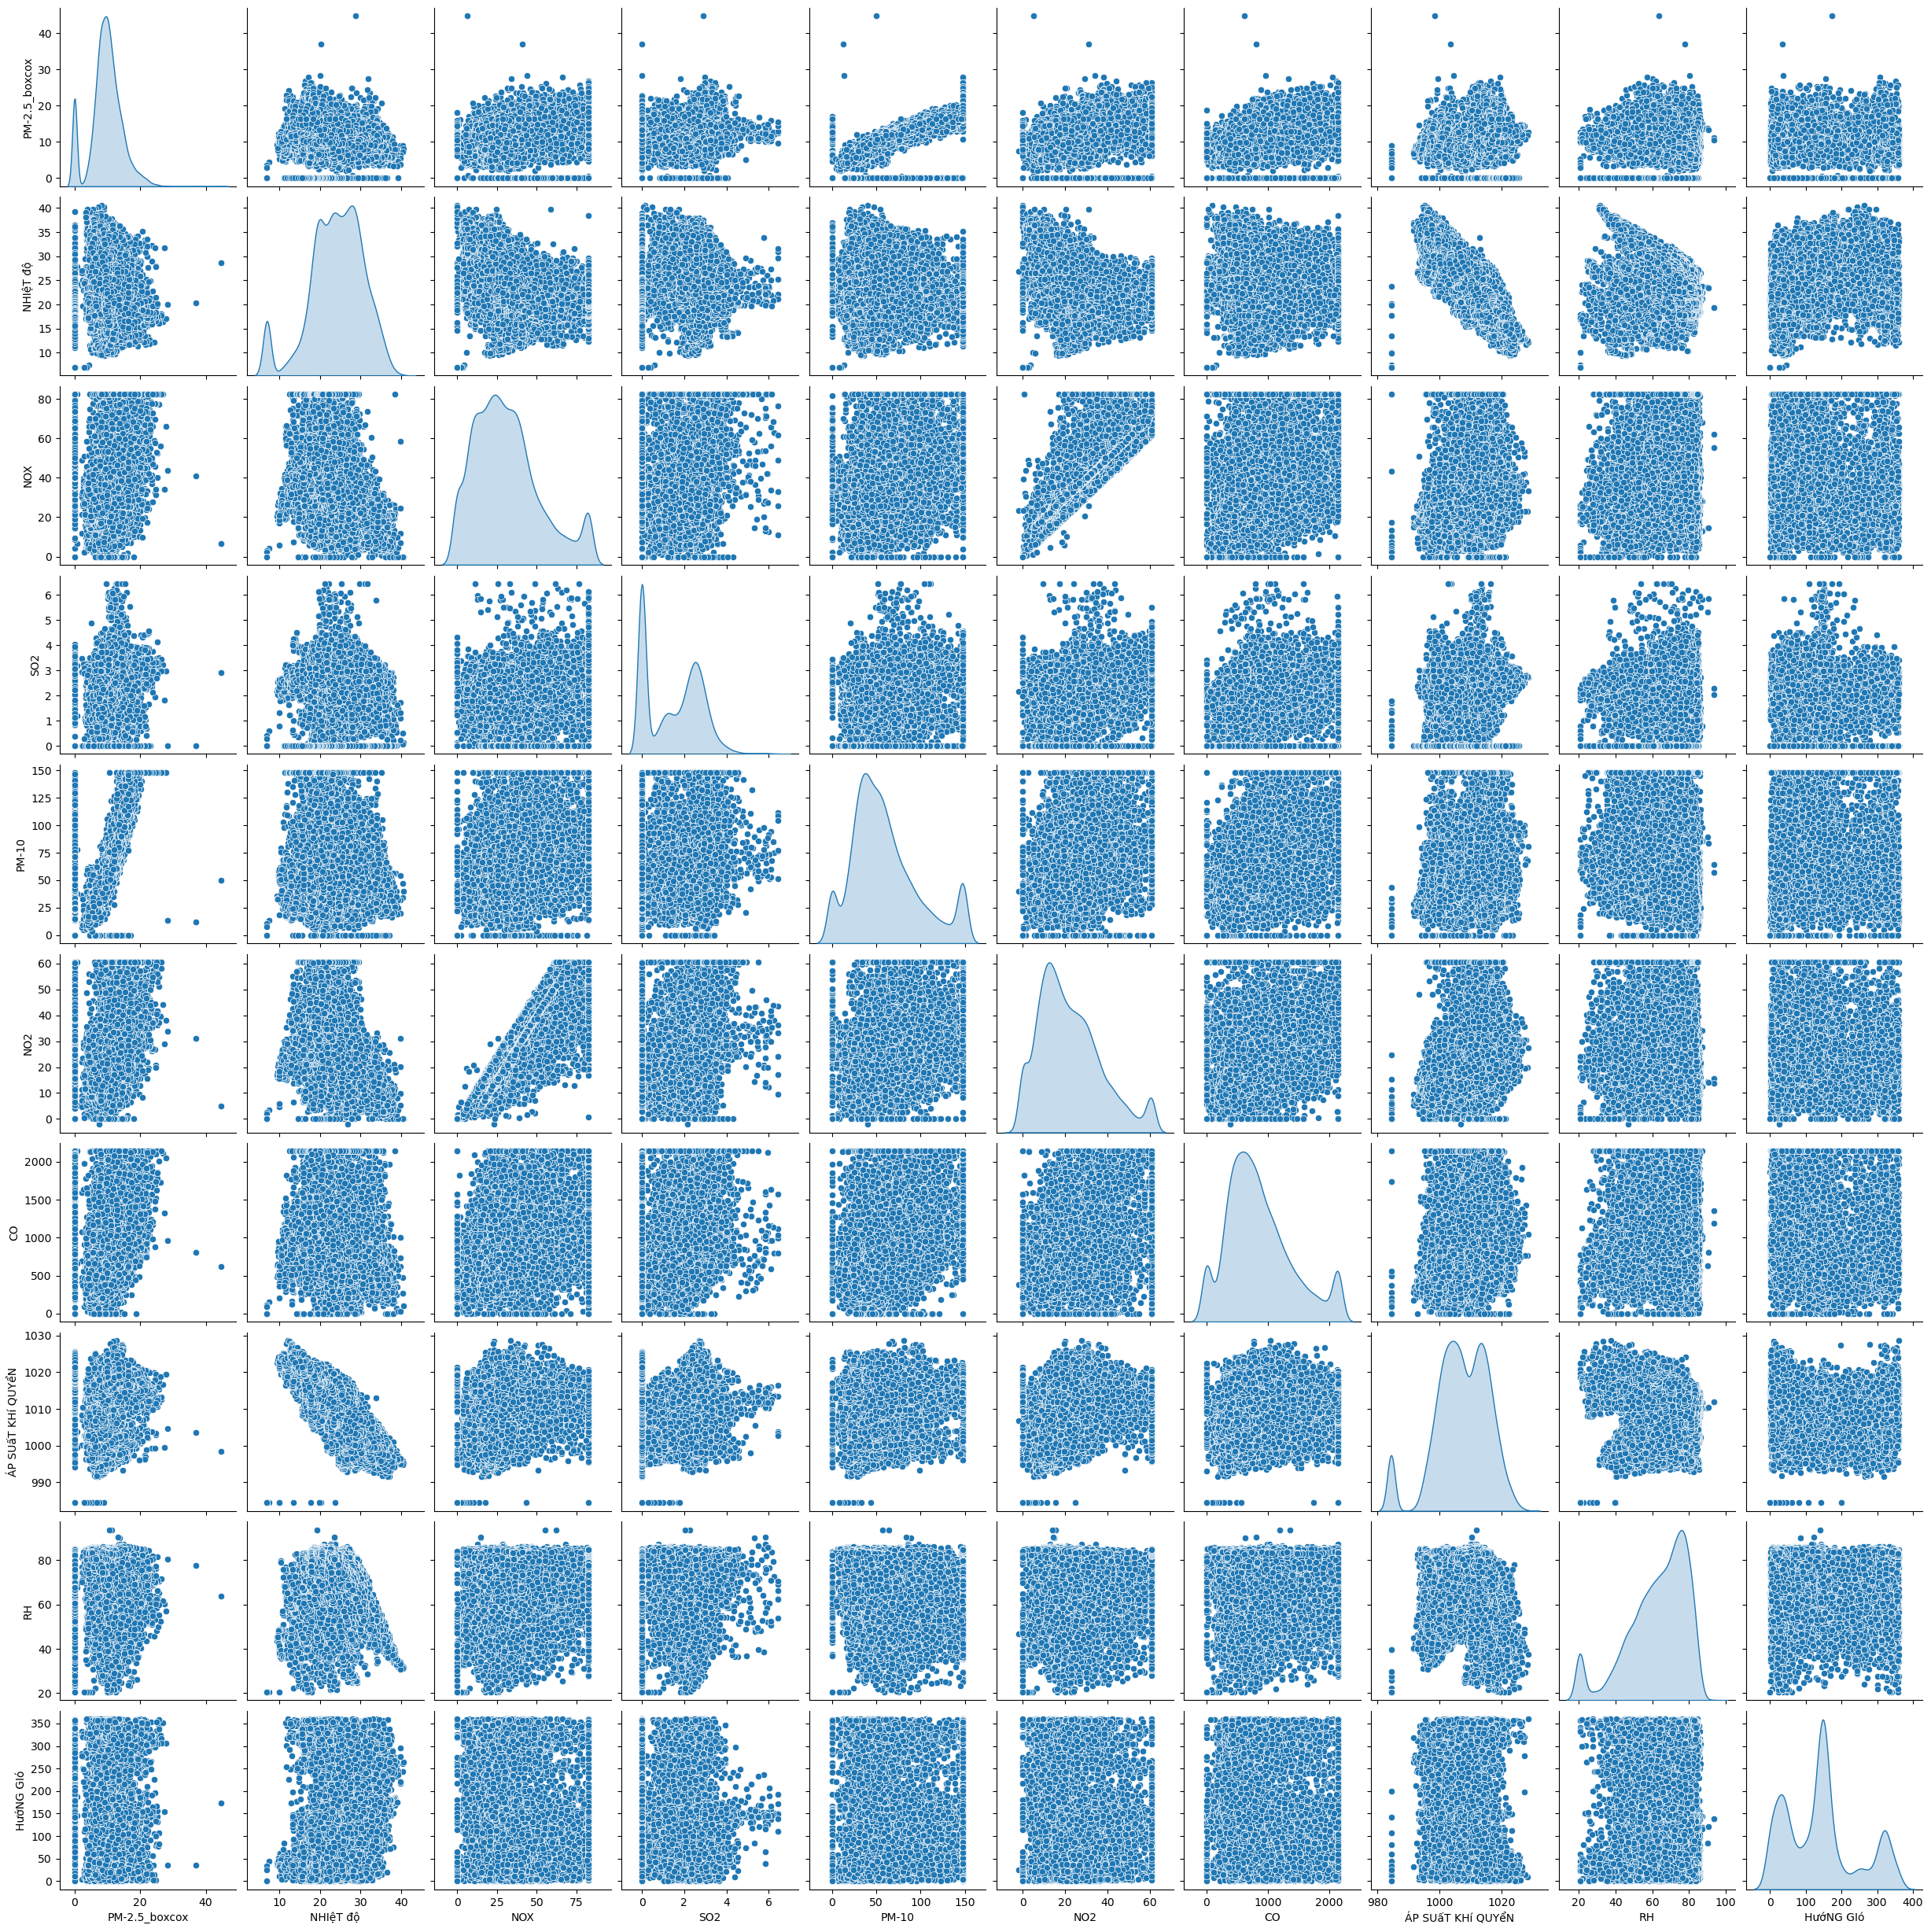

In [57]:
sns.pairplot(df, vars=['PM-2.5_boxcox', 'NHIệT độ', 'NOX', 'SO2', 'PM-10', 'NO2', 'CO', 'ÁP SUấT KHí QUYểN', 'RH', 'HướNG GIó'], diag_kind='kde')
plt.show()

Pair plots show how PM2.5 relates to other features 

Standardizing or normalizing these features which have vastly different scales, ensures that the regression model treats all inputs equally, avoiding bias towards larger-scale features.

In [58]:
scale = StandardScaler()

features_to_scale = ['NHIệT độ', 'NOX', 'SO2', 'PM-10', 'NO2', 'CO', 'ÁP SUấT KHí QUYểN', 'RH', 'HướNG GIó']

df[features_to_scale] = scale.fit_transform(df[features_to_scale])

df['PM-2-5'] = scale.fit_transform(df[['PM-2-5']])

In [59]:
df[features_to_scale + ['PM-2-5'] + ['PM-2.5_boxcox']].head()

,NHIệT độ,NOX,SO2,PM-10,NO2,CO,ÁP SUấT KHí QUYểN,RH,HướNG GIó,PM-2-5,PM-2.5_boxcox
0,-0.281700,0.840277,3.821898,0.428711,0.742557,0.262117,0.722873,0.409314,0.067542,0.451745,12.416599
1,-0.387898,1.526984,3.681604,0.405935,1.086773,-0.126349,0.746370,0.633960,0.077482,0.373499,12.098718
2,-0.418240,1.505780,3.136014,0.344756,0.988134,0.066095,0.734622,0.565318,0.047662,0.484172,12.546323
3,-0.433411,1.469638,3.837487,0.462876,0.949359,0.487702,0.722873,0.490436,0.057602,0.566647,12.871236
4,-0.463753,2.456146,3.011308,0.243851,1.433711,-0.388087,0.699375,0.671401,0.057602,0.516950,12.676306


In [60]:
from sklearn.model_selection import train_test_split

X = df[features_to_scale]
y1 = df['PM-2.5_boxcox']
y2 = df['PM-2-5']

X_train, X_test, y_train_1, y_test_1 = train_test_split(X, y1, test_size=0.3, random_state=42)
X_train, X_test, y_train_2, y_test_2 = train_test_split(X, y2, test_size=0.3, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 9604, Testing samples: 4116


I'll start by testing 7 models and compare their Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² score.

In [61]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05,
                         colsample_bytree=0.8, subsample=0.8,
                         max_depth=6, random_state=42)

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.05,
                           subsample=0.8, max_depth=6, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)

stacking_model = StackingRegressor(
    estimators=[('xgb', xgb_model),
                ('lgbm', lgbm_model),
                ('rf', rf_model)],
    final_estimator=Lasso(alpha=0.1)
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "Stacking Model": stacking_model
}

In [62]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2}

In [63]:
trained_models_1 = {name: model.fit(X_train, y_train_1) for name, model in models.items()}
results_1 = {name: evaluate_model(model, X_train, X_test, y_train_1, y_test_1) for name, model in trained_models_1.items()}

trained_models_2 = {name: model.fit(X_train, y_train_2) for name, model in models.items()}
results_2 = {name: evaluate_model(model, X_train, X_test, y_train_2, y_test_2) for name, model in trained_models_2.items()}

results_df_1 = pd.DataFrame(results_1).T
results_df_2 = pd.DataFrame(results_2).T

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000618 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2274
[LightGBM] [Info] Number of data points in the train set: 9604, number of used features: 9
[LightGBM] [Info] Start training from score 9.521625
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [64]:
print("Results for PM-2-5-boxcox:")
results_df_1

Results for PM-2-5-boxcox:


,MAE,MSE,RMSE,R2 Score
Linear Regression,2.067005,10.664860,3.265710,0.515888
Ridge Regression,2.067023,10.664783,3.265698,0.515891
Lasso Regression,2.099375,10.734598,3.276370,0.512722
Random Forest,1.407065,5.622845,2.371254,0.744761
XGBoost,1.233486,4.308602,2.075717,0.804419
LightGBM,1.250884,4.496025,2.120383,0.795911
Stacking Model,1.229520,4.279222,2.068628,0.805752


In [65]:
print("\nResults for PM-2-5:")
results_df_2


Results for PM-2-5:


,MAE,MSE,RMSE,R2 Score
Linear Regression,0.381567,0.405526,0.636809,0.571106
Ridge Regression,0.381562,0.405523,0.636807,0.571110
Lasso Regression,0.382321,0.421799,0.649461,0.553895
Random Forest,0.280530,0.216909,0.465735,0.770592
XGBoost,0.246135,0.168320,0.410269,0.821980
LightGBM,0.250731,0.178558,0.422561,0.811153
Stacking Model,0.266106,0.182600,0.427318,0.806878


This result show that Stacking Model is the best because "MAE", "MSE", "RMSE" are lowest and R2 score is highest. Hence, i start to fine-tune this model with hyperparameter tuning.

In [66]:
from sklearn.model_selection import GridSearchCV

xgb_params = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6, 9]
}

lgbm_params = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

rf_params = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20]
}

xgb_search = GridSearchCV(XGBRegressor(random_state=42), xgb_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
lgbm_search = GridSearchCV(LGBMRegressor(random_state=42), lgbm_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
rf_search = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)

xgb_search.fit(X_train, y_train_2)
lgbm_search.fit(X_train, y_train_2)
rf_search.fit(X_train, y_train_2)

xgb_best = xgb_search.best_estimator_
lgbm_best = lgbm_search.best_estimator_
rf_best = rf_search.best_estimator_

print("Best XGBoost Params:", xgb_search.best_params_)
print("Best LightGBM Params:", lgbm_search.best_params_)
print("Best Random Forest Params:", rf_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000623 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2274
[LightGBM] [Info] Number of data points in the train set: 9604, number of used features: 9
[LightGBM] [Info] Start training from score -0.000701
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
Best LightGBM Params: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 50}
Best Random Forest Params: {'max_depth': 20, 'n_estimators': 300}


In [67]:
base_models = [
    ('XGBoost', xgb_best),
    ('LightGBM', lgbm_best),
    ('RandomForest', rf_best)
]

ridge_params = {'alpha': [0.1, 1.0, 10.0]}
grid_search = GridSearchCV(Ridge(), ridge_params, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train_2)

best_ridge = grid_search.best_estimator_
print("Best Ridge Alpha:", grid_search.best_params_)

stacking_model = StackingRegressor(estimators=base_models, final_estimator=best_ridge, verbose=1)

stacking_model.fit(X_train, y_train_2)

y_pred_stacking = stacking_model.predict(X_test)

mae = mean_absolute_error(y_test_2, y_pred_stacking)
mse = mean_squared_error(y_test_2, y_pred_stacking)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_2, y_pred_stacking)

print(f"Stacking Model Performance:\n MAE: {mae}, MSE: {mse}, RMSE: {rmse}, R2 Score: {r2}")

Best Ridge Alpha: {'alpha': 10.0}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2274
[LightGBM] [Info] Number of data points in the train set: 9604, number of used features: 9
[LightGBM] [Info] Start training from score -0.000701
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2273
[LightGBM] [Info] Number of data points in the train set: 7683, number of used features: 9
[LightGBM] [Info] Start training from score 0.002312
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise mult

In [72]:
models = {
    "XGBoost": xgb_best,
    "LightGBM": lgbm_best,
    "RandomForest": rf_best,
    "Stacking Model": stacking_model
}

mae_scores = {}
rmse_scores = {}
r2_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae_scores[name] = mean_absolute_error(y_test_2, y_pred)
    rmse_scores[name] = np.sqrt(mean_squared_error(y_test_2, y_pred))
    r2_scores[name] = r2_score(y_test_2, y_pred)

model_names = list(models.keys())
mae_values = list(mae_scores.values())
rmse_values = list(rmse_scores.values())
r2_values = list(r2_scores.values())

C:\Users\tranl\AppData\Local\Temp\ipykernel_2592\2574858899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mae_values, ax=ax[0], palette="viridis")
C:\Users\tranl\AppData\Local\Temp\ipykernel_2592\2574858899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=rmse_values, ax=ax[1], palette="coolwarm")
C:\Users\tranl\AppData\Local\Temp\ipykernel_2592\2574858899.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_values, ax=ax[2], palette="magma")


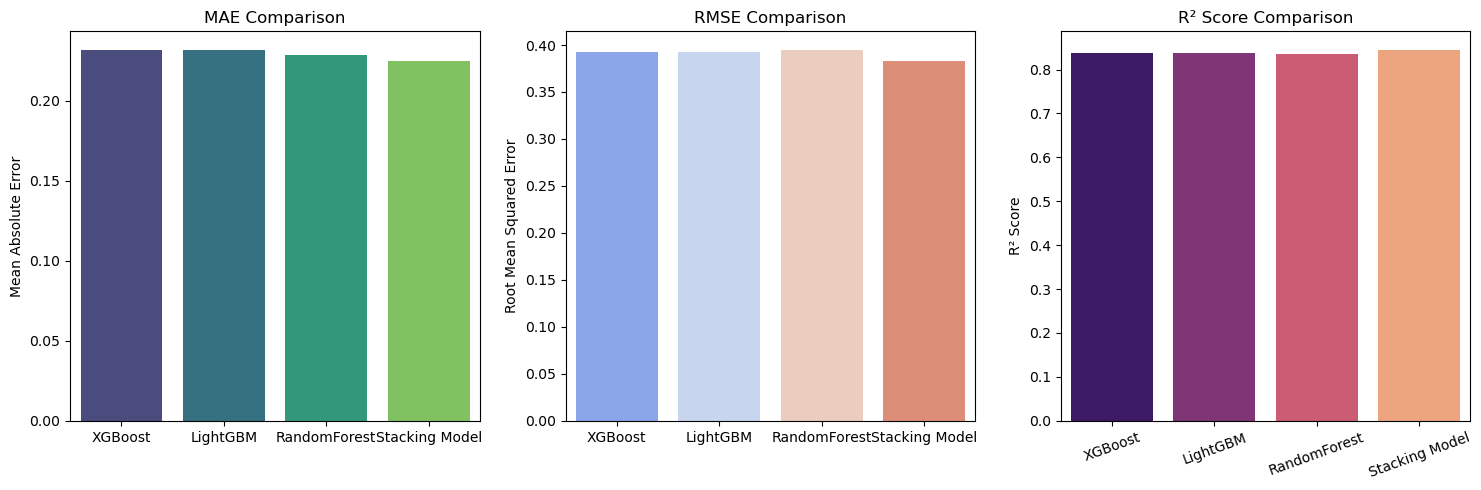

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(x=model_names, y=mae_values, ax=ax[0], palette="viridis")
ax[0].set_title("MAE Comparison")
ax[0].set_ylabel("Mean Absolute Error")

sns.barplot(x=model_names, y=rmse_values, ax=ax[1], palette="coolwarm")
ax[1].set_title("RMSE Comparison")
ax[1].set_ylabel("Root Mean Squared Error")

sns.barplot(x=model_names, y=r2_values, ax=ax[2], palette="magma")
ax[2].set_title("R² Score Comparison")
ax[2].set_ylabel("R² Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


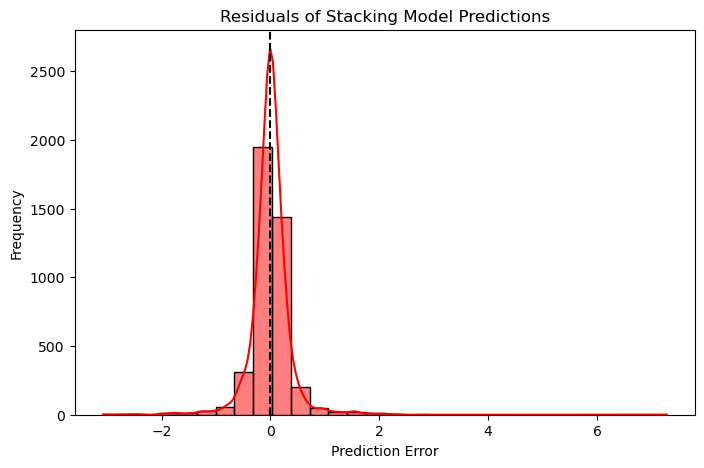

In [71]:
y_pred_stacking = stacking_model.predict(X_test)
residuals = y_test_2 - y_pred_stacking

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color="red")
plt.axvline(0, color='black', linestyle='dashed', linewidth=1.5)
plt.title("Residuals of Stacking Model Predictions")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()


Now, after re-train Stacking model with hyperparameter, i conducted performance evaluation by visualizing.

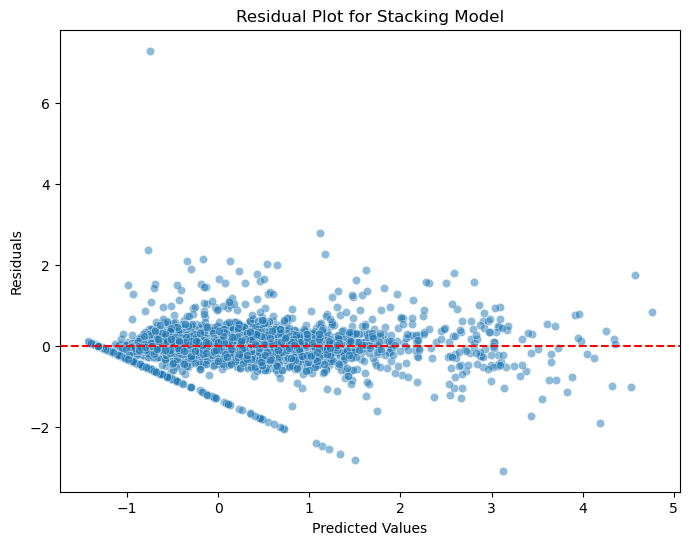

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_stacking, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Stacking Model")
plt.show()

First, i use a residual plot to shows the difference between actual and predicted values. The residuals are randomly scattered around zero so that the model performs well.

Next, i evaluate how close the predictions are to actual values by making a perfect prediction line.

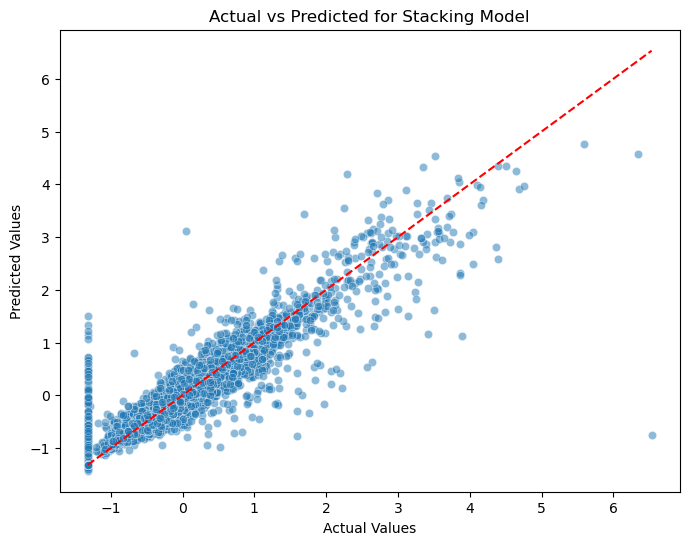

In [69]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_2, y=y_pred_stacking, alpha=0.5)
plt.plot([min(y_test_2), max(y_test_2)], [min(y_test_2), max(y_test_2)], color='red', linestyle="--")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted for Stacking Model")
plt.show()